# Practica 02: Agrupaciones

Para ir ejecutando el cuaderno python usamos Shift+Intro.  

In [2]:
# Esto se emplea para que la salida se adapte al formato del notebook a partir de notebook 7 se usa ipympl en vez de notebook
%matplotlib ipympl
# A continuación importamos librerías necesarias  
import numpy as np  # cálculo numérico
import matplotlib.pyplot as plt  # gráficos 
from matplotlib import cm

## Aproximación de campo lejano

La aproximación de campo lejano es razonable. Para hacernos una idea
vamos a calcular una diferencia de caminos de forma exacta y con la
aproximación de campo lejano. Fijémonos en el orden del error respecto
a la longitud de onda. El producto escalar entre dos arrays numpy se
puede representar mediante el signo arroba.

In [3]:
def respuesta_01():
    # Dos fuentes puntuales generan dos ondas esféricas escalares.
    # de longitud de onda λ.
    #
    # Cada frente de onda esférico siempre tiene como centro la fuente
    # puntual que ha generado la onda. Las ondas parten en fase. De modo
    # que la fase con la que se superfonen ambas ondas en el punto de
    # observación únicamente depende de la diferencia de longitud entre
    # los caminos que ha recorrido cada una de las dos ondas hasta llegar
    # al observador. Las dos fuentes puntuales son:
    # 1) una fuente puntual centrada en 𝐫⃗_src1=[x=0,y=0,z=0]
    # 2) otra fuente puntual en 𝐫⃗_src2=[x=1,y=2,z=1]. 
    # El punto de observación es 𝐫⃗_obs=[x=100,y=150,z=200])
    # Pista: utiliza 𝐫̂_obs, el unitario en la dirección del obsevador
    # Calcular la diferencia de caminos longitud_camino_1-longitud_camino_2 
    # sin usar la aproximación de campo lejano y después usando la
    # aproximación de campo lejano.

    λ=5 # longitud de onda de 5 metros

    # Edita a partir de aquí  
    
    s1= np.array((0,0,0))
    s2= np.array ((1,2,1))
    obs= np.array ((100,150,200))

    obsmod = np.linalg.norm(obs)
    camino1= np.linalg.norm(obs-s1)
    camino2= np.linalg.norm(obs-s2)

    obsnorm= obs/obsmod

    diferencia_caminos_sin_aproximar= camino1 - camino2
    diferencia_de_caminos_en_campo_lejano=np.dot(obsnorm, s2)
    return(diferencia_caminos_sin_aproximar, diferencia_de_caminos_en_campo_lejano)

respuesta_01()

(np.float64(2.226407048409669), np.float64(2.2283440581246223))

## Factor de agrupación (FA) de dos fuentes puntuales

El factor de agrupación nos permite resolver en dos partes el problema
de una agrupación de antenas. Por el principio de multiplicación de
diagramas, por un lado se puede resolver el campo creado por un
elemento de la agrupación centrado en el origen y por otro el factor
de agrupación. El campo del elemento en el origen es el término que
contiene el caracter vectorial y la atenuación con la distancia para
conservar la energía. El factor de agrupación nos da el diagrama
direccional de interferencia, usando las diferencias de caminos y los
fasores de las corrientes de alimentación. Las posiciones de los
centros de fase de cada antena de la agrupación, determinan esas
diferencias de camino. La diferencias de camino, junto con los
desfases temporales dan lugar a la fase de la señal observada mediante
superposición de fasores.

In [4]:
def respuesta_02():
    # Calcular el factor de agrupación asociado a las dos fuentes puntuales
    # anteriores evaluado en la dirección del punto de observación del
    # problema anterior (recuerda que es un número complejo).
    # La fuente en el origen tiene fase cero y la otra está adelantada
    # un cuarto de periodo temporal y oscila con el triple de amplitud.
    # Asumimos campo lejano.
    # Edita a partir de aquí
    λ=5
    diferencia_de_caminos=respuesta_01()[1]
    FA=1+3*1j*np.exp(1j*2*np.pi/λ*diferencia_de_caminos)
    return(FA)    

respuesta_02()

np.complex128(-0.004343325296739753-2.826887773671231j)

## Agrupación lineal transversal

Gracias a la aproximación de campo lejano, podemos emplear la
Transformada de Fourier (TF) para calcular el factor de agrupación (FA)
como una TF discreta de la secuencia de coeficientes.

interactive(children=(FloatSlider(value=0.0, description='$\\Psi_z=>\\Theta$', max=180.0, step=0.01), Output()…

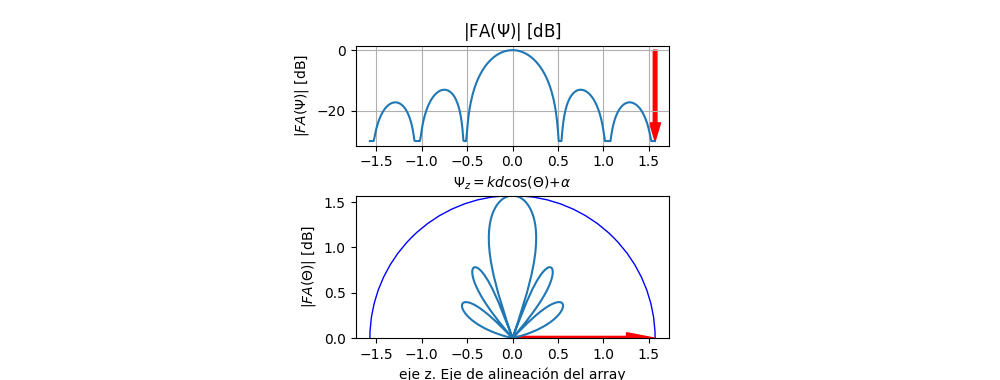

In [5]:
def respuesta_03():
    # Consideramos una agrupación de 12 antenas isotrópicas 
    # Es una agrupación uniforme: las 12 antenas están alimentadas 
    # por corrientes de la misma amplitud y fase.
    # Los centros de fase de los elementos de la agrupación están 
    # alineados en el eje z.
    # La distancia de separación entre las antenas es de media 
    # longitud de onda (d=λ/4).
    # Valor del FA en Ψ=0 es 1.
    # Fase progresiva nula (α=0)
    # Esta función debe devolver una lista con dos elementos:
    # El primero será valor absoluto del factor de agrupación en
    # función de Ψ, es decir |FA(Ψ)|.
    # El segundo una  lista con otros dos elementos: los extremos
    # del margen visible es decir los extremos del intervalo de 
    # Ψ que se corresponden con direcciones del espacio real.
    # Observa en el gráfico generado abajo, la relación uno a uno 
    # entre Ψ y θ.
    # Edita a partir de aquí 
   
    FA=lambda psi: abs(sum(np.exp(1j * psi * n) for n in range(12)))/12

    # [-kd + alfa, kd +alfa]
    # alfa = 0
    margen_visible = [-np.pi / 2, np.pi / 2]
    return [FA,margen_visible]
    

    FA_vectorizado = np.vectorize(FA)
    return [FA,margen_visible]

from ftrlearn02 import muestra_FA
muestra_FA(respuesta_03()[0],respuesta_03()[1], r'|FA($\Psi$)| [dB]')

## Agrupación uniforme con análisis de fase progresiva

Vamos a analizar ahora la importancia de las diferencias de fase en la
alimentación de los elementos de la agrupación. Veamos cómo los
desfases temporales progresivos producen desplazamientos en frecuencia
espacial. Como las frecuencias espaciales están asociadas a distintas
direcciones de observación, se produce una rotación del diagrama. Es
decir una hay una rotación en el patrón del reparto espacial de energía.

<>:25: SyntaxWarning: invalid escape sequence '\P'
<>:25: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_25432\3915439260.py:25: SyntaxWarning: invalid escape sequence '\P'
  muestra_FA(respuesta_04()[0],respuesta_04()[1],'|FA($\Psi$)| [dB]')


interactive(children=(FloatSlider(value=0.0, description='$\\Psi_z=>\\Theta$', max=180.0, step=0.01), Output()…

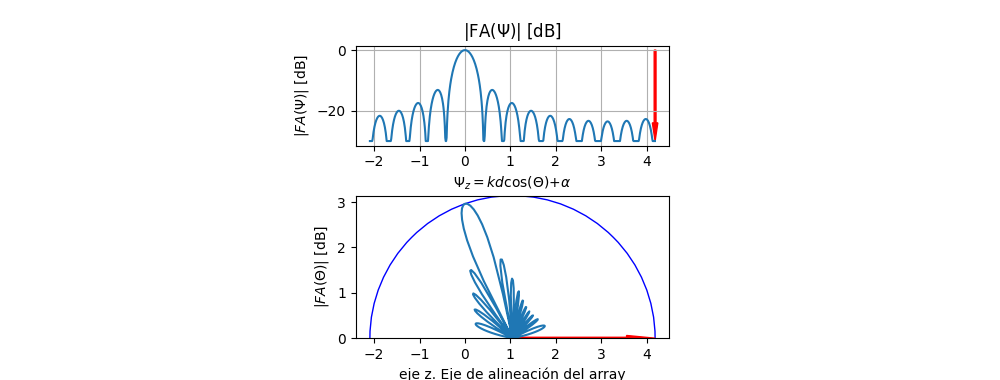

np.float64(109.47122063449069)

In [6]:
def respuesta_04():
    # Consideramos una agrupación uniforme de 15 antenas isotrópicas 
    # Los centros de fase de los elementos de la agrupación están 
    # alineados en el eje z. La distancia de separación entre las 
    # antenas es d=λ/2. La fase progresiva α es de 60 grados.
    # La escala vertical del FA es tal que FA(Ψ=0)=1.
    #
    # Esta función debe devolver una lista con tres elementos:
    # - el primero el valor del módulo del factor de agrupación en 
    #   función de psi: |FA(Ψ)|
    # - el segundo una lista con otros dos elementos: los extremos 
    #   del margen visible.
    # - el tercero el valor θ expresado en grados en el que se 
    # alcanza el máximo de radiación (chequea a ojo si se corresponde 
    # con ayuda de la gráfica)
    # Edita a partir de aquí
   
    FA=lambda psi: abs(sum(np.exp(1j * psi * n) for n in range(15)))/15
    α = np.pi/3
    margen_visible=[-2*np.pi/3,4*np.pi/3]
    
    theta_max=np.arccos(-α/np.pi)*180/np.pi
    return [FA,margen_visible,theta_max]

muestra_FA(respuesta_04()[0],respuesta_04()[1],'|FA($\Psi$)| [dB]')
respuesta_04()[2] #imprime el theta_max

## Agrupación uniforme con cálculo de fase progresiva

interactive(children=(FloatSlider(value=0.0, description='$\\Psi_z=>\\Theta$', max=180.0, step=0.01), Output()…

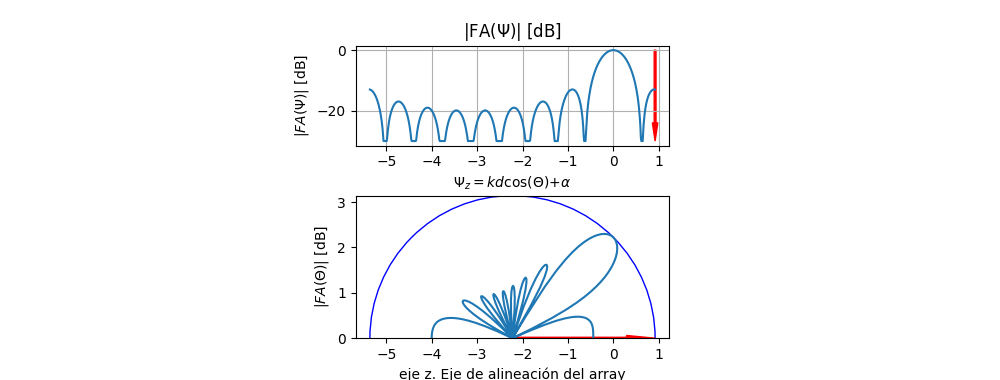

np.float64(-2.221441469079183)

In [7]:
def respuesta_05():
    # Consideramos una agrupación de 10 antenas isotrópicas 
    # Los centros de fase de los elementos de la agrupación
    # están alineados en el eje z. La distancia de separación
    # entre las antenas es d=λ/2.
    # Calcular la fase progresiva alpha para que el máximo de
    # radiación esté en Θ_max=45 grados, apuntando hacia la
    # bisectriz del primer cuadrante. La escala vertical del
    # FA es tal que FA(Ψ=0)=1.
    # Esta función debe devolver una lista con tres elementos:
    # - el primero la valor del módulo del factor de agrupación en 
    #   función de psi 
    # - el segundo una lista con otros dos elementos: los extremos 
    #   del margen visible.
    # - el tercero el valor alpha expresado en radianes. 
    # (chequea a ojo si se está bien con ayuda de la gráfica)
    # Edita a partir de aquí
    
    alpha=-np.pi*np.cos(np.pi/4)
    FA=lambda psi: abs(sum(np.exp(1j * psi * n) for n in range(10)))/10
    
    margen_visible=[-np.pi+alpha,+np.pi+alpha]
    return [FA,margen_visible,alpha]
muestra_FA(respuesta_05()[0],respuesta_05()[1], r'|FA($\Psi$)| [dB]')
respuesta_05()[2] # imprime el alpha

Necesitamos aprender a representar superficies con matplotlib. El
proceso es similar en matlab.

- Una superficie z=f(x,y) se puede aproximar mediante parches
  rectangulares.
- Cada uno de esos parches vendrá determinado por las coordenadas de
  sus cuatro esquinas.
- Cada esquina se representaría como un punto en 3D: (x,y,f(x,y)).
- Imaginemos que queremos representar la superficie formada por 6
  parches contiguos: dos filas con tres columnas de parches cada una.
- Primero necesitamos encontrar las coordenadas de las esquinas de
  cada parche.
- Como los parches son contiguos hay muchas esquinas que forman parte
  de varios parches.
- No tiene sentido repetir varias veces las coordenadas de la misma
  esquina.
- La idea es indicar a qué parche pertenece cada esquina de
  coordenadas (x,y) utilizando una matriz.
- La posición en la matriz indíca los parches a los que pertenece. Por
  ejemplo

<img src="figuras/meshgrid-example.png" alt="ejemplo meshgrid" class="bg-primary mb-1" width="500px">

- En el gráfico de arriba, las coordenadas (x,y)=(1,7) representan la
  esquina superior izquierda del parche superior izquierdo.
- Las coordenadas (2,7), (1,6) y (2,6) son el resto de esquinas de
  este primer parche.
- El segundo parche de la primera fila comparte dos esquinas con el
  parche anterior: (2,7) y (2,6). Además tiene otras dos equinas
  nuevas (3,7) y (3,6)
- De modo que la posición en la matriz determina cuáles son las
  coordenadas (x,y) de las esquinas de cada uno de los seis parches.

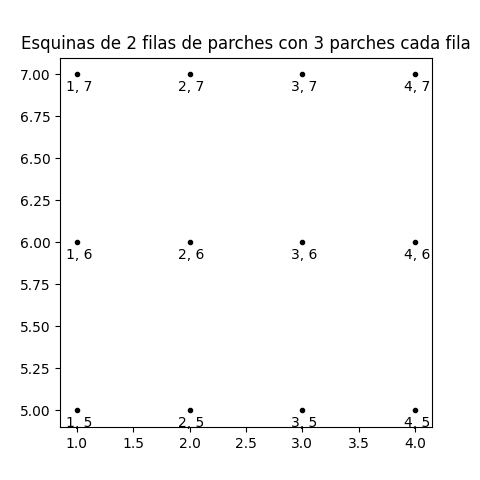

In [8]:
def muestra_meshgrid():
    # Instanciamos la figura
    fig = plt.figure(figsize=plt.figaspect(1))
    # Defino las coordenadas x de las esquinas de los parches
    x = np.array([1, 2, 3, 4])
    # Defino las coordenadas y de las esquinas de los parches
    y = np.array([5, 6, 7])
    # Creo la malla de coordenadas con las esquinas de los parches
    XX, YY = np.meshgrid(x, y)
    # Dibujo un punto en cada esquina de los parches
    plt.plot(XX, YY, marker='.', color='k', linestyle='none')
    # Etiqueto los puntos
    for i in x:
        for j in y:
            plt.text(i-0.1, j-0.1, '%d, %d' % (int(i), int(j))) #, transform=trans_offset)
    
    ax=fig.gca()
    ax.set_title("Esquinas de 2 filas de parches con 3 parches cada fila")            
    
    plt.show()

muestra_meshgrid()

Para representar la función z=f(x,y)=x empleamos la malla que hemos creado en en plano xy:

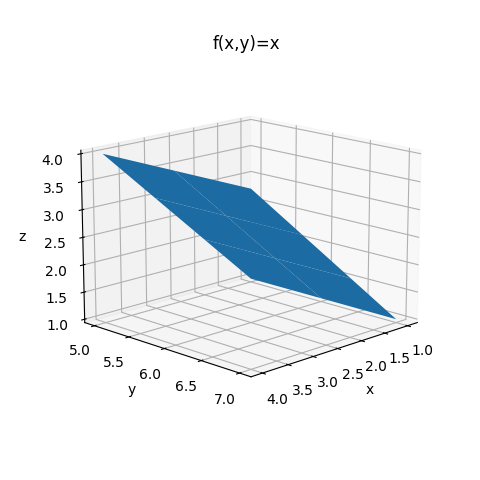

In [9]:
def muestra_superficie_con_meshgrid():
    fig = plt.figure(figsize=plt.figaspect(1))
    ax = fig.add_subplot(111, projection='3d')   
    # Defino las coordenadas x de las esquinas de los parches
    x = np.array([1, 2, 3, 4])
    # Defino las coordenadas y de las esquinas de los parches
    y = np.array([5, 6, 7])
    # Creo la malla de coordenadas con las esquinas de los parches
    XX, YY = np.meshgrid(x, y)
    # Esta función crea los parches identificando las esquinas comunes de forma automática
    ax.plot_surface(XX, YY, XX)
    # Etiquetamos los ejes
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    # Damos título a la gráfica
    ax.set_title('f(x,y)=x')
    # Seleccionamos un punto de vista inicial
    ax.view_init(15,45)
    # Mostramos la gráfica
    plt.show()
    
muestra_superficie_con_meshgrid()

Vemos los 6 parches con las esquinas definidas por la malla de puntos
que vimos antes. La altura de cada punto la hemos fijado en este
ejemplo al valor de la coordenada x de la malla, pero con mayor
generalidad pordemos dar a cada esquina del parche la altura que
queramos en función de sus cordenadas (x,y)

## Representación del FA 2D en cartesianas

Ahora nuestro objetivo es representar la transformada bidimensional de
los coeficientes de alimentación de una agrupación plana.

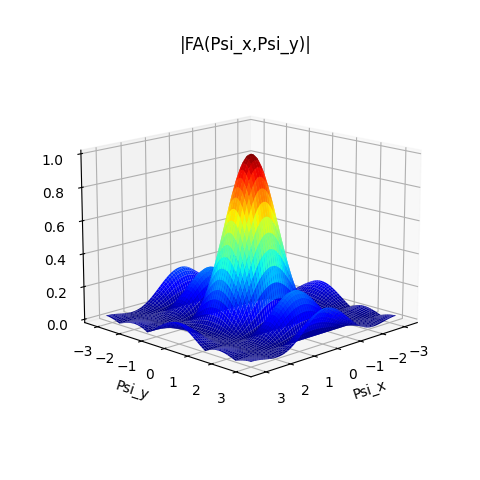

In [10]:
def respuesta_06():
    # Esta función debe devolver tres matrices para representar 
    # un Factor de Agrupación en módulo: |FA(Ψ_x,Ψ_y)|
    # PSI_y es la matriz de coordenadas Ψ_y de la malla de 
    # evaluación, queremos mostrar un periodo en ese eje, en 
    # intervalo simétrico respecto al origen, con 70 segmentos.
    # PSI_x es la matriz de coordenadas Ψ_x de la malla de 
    # evaluación, queremos mostrar un periodo en ese eje, en 
    # intervalo simétrico respecto al origen, con 70 segmentos
    # FA es la matriz de valores del Factor de agrupación 
    # correspondientes a la malla de evaluación (70x70 parches)
    # Se trata de una agrupación triangular en x, uniforme en y. 
    # Formada por una matriz cuadrada de 5 elementos de lado 
    # (25 antenas). Está normalizada en el origen vale 1.
    # Edita a partir de aquí

    # Definimos x e y con valores en el intervalo [-π, π], dividido en 70 segmentos.
    x = np.linspace(-np.pi, np.pi, 70+1) 
    y = np.linspace(-np.pi, np.pi, 70+1) 
    PSI_x, PSI_y = np.meshgrid (x,y)
    #es triangular (apuntes tema 2 2.4.3)
    #la normalizacion debe reflejar la suma de los coeficientes (1+2+3+2+1)
    FA_x=(1/9)*np.abs(1+2*np.exp(1j*PSI_x)+ 3*np.exp(2j*PSI_x)+2*np.exp(3j*PSI_x)+np.exp(4j*PSI_x))
    FA_y=(1/5)*np.abs(1+np.exp(1j*PSI_y)+ np.exp(2j*PSI_y)+np.exp(3j*PSI_y)+np.exp(4j*PSI_y))    

    FA= FA_y*FA_x
    return([PSI_x,PSI_y,FA])

from ftrlearn02 import muestra_FA_cartesianas   
muestra_FA_cartesianas(respuesta_06()[0],respuesta_06()[1],respuesta_06()[2],'|FA(Psi_x,Psi_y)|')

## 

## Representación del FA 2D en unidades logarítmicas

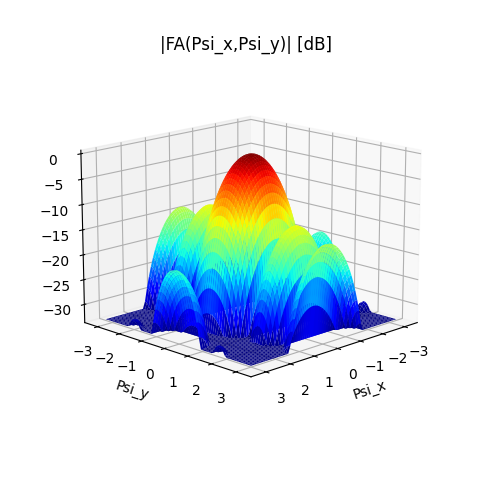

In [11]:
def respuesta_07():
    # Esta función debe devolver tres matrices para representar 
    # un Factor de Agrupación en módulo: |FA(Ψ_x,Ψ_y)| de la 
    # respuesta anterior, pero el eje vertical ahora tiene estar
    # expresado en dB relativos respecto al máximo principal,
    # que debe valer 0 dB.
    # En la gráfica se mostrarán valores hasta -33 dB todos los 
    # valores inferiores se sustituirán por -33 dB
    # Podemos comprobar que se aprecian mejor los lóbulos secundarios
    # Edita a partir de aquí
    PSI_x,PSI_y,FA=respuesta_06()
    FA_log=20*np.log10(FA/np.amax(FA))
    #amax encuentra el valor maximo de la matriz FA. para normalizar la matriz
    #de manera que el valor máximo de fA se convierta en 0db
    FA_log[FA_log< -33]= -33
    #los valores por debajo de -33 pasan a valer -33
    return([PSI_x,PSI_y,FA_log])

muestra_FA_cartesianas(respuesta_07()[0],respuesta_07()[1],respuesta_07()[2],'|FA(Psi_x,Psi_y)| [dB]')

## Principio de multiplicación de diagramas

El principio de multiplicación de diagramas nos permite resolver por
separado el diagrama de radiación de un elemento del array y luego
conseguir el diagrama de la agrupación multiplicando por el factor de la
agrupación
-

In [12]:
def respuesta_08():
    # Agrupación uniforme
    # Centros de cada antena sobre el eje X.
    # La distancia de separación entre las antenas es d=λ/2.
    # Fase progresiva nula.
    # Se usan 5 antenas de hilo iguales entre sí. 
    # Cada una de ellas tiene un campo radiado ∣E∣^2=|sin(θ)|^2 
    # cuando están paralelas al eje z, como es el caso.
    # La función devuelve el diagrama de radiación t(θ,φ) de 
    # densidad de potencia normalizado de la agrupación en 
    # unidades naturales
    # Edita a partir de aquí
    #hola
    E = lambda θ: np.abs(np.sin(θ))**2
    #φ se mide en el plano XY y define la dirección alrededor del eje Z
    #la diferencia de fase depende de cómo las distancia entre antenas
    #(alineadas en X) se proyecta sobre la dirección de observación
    #se usa φ porque las antenas están sobre el eje X
    #sin(θ) (θ que tan alejado) cuanta de la distancia se proyecta en el plano horizontal (XY)
    #cos(φ) cuanto de esa proyección en el plano XY está en la dirección del eje X

    FA=lambda θ,φ:((np.abs(sum([np.exp(1j * np.pi*np.sin(θ) * np.cos(φ) * n) for n in range(5)]))**2)/25)*E(θ)
    return FA



## El FA 2D en el espacio real

Las agrupaciones planas son una extensión de las agrupaciones
unidimensionales. En muchas ocasiones se puede estudiar una agrupación
plana como la convolución de dos agrupaciones lineales.

<>:26: SyntaxWarning: invalid escape sequence '\P'
<>:26: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_25432\982393731.py:26: SyntaxWarning: invalid escape sequence '\P'
  muestra_FA_2D(respuesta_09()[0],respuesta_09()[1],respuesta_09()[2],'|FA($\Psi$)| [dB]')


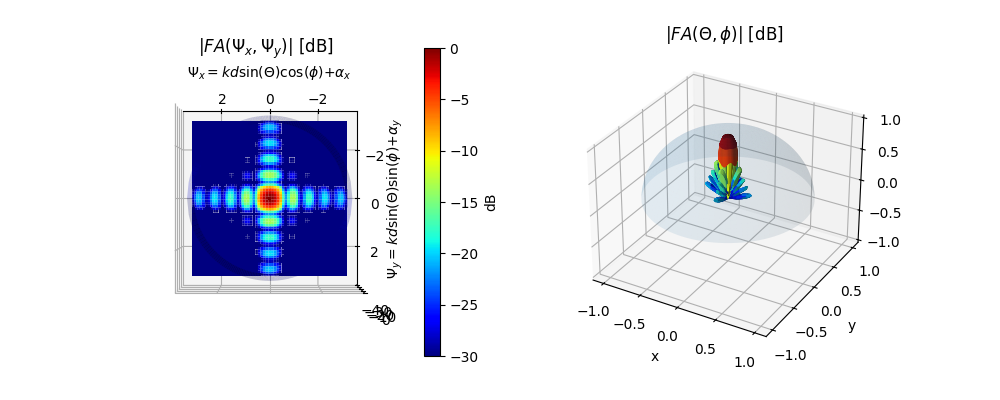

In [13]:
def respuesta_09():
    # Se considera:
    # Una agrupación de antenas isotrópicas sobre el plano XY
    # Repartidas en los nodos de una malla cuadrada de 10x10 elementos.
    # La separación entre elementos es de media longitud de onda en 
    # la dirección X, también en la dirección Y
    # Alimentación uniforme
    # En el origen el FA(Ψx=0,Ψy=0)=1
    # Diagrama de radiación en el espacio real con el lóbulo principal 
    # apuntando en la dirección (θ=0)
    # La función devuelve tres cosas:
    # - Factor de agrupación en módulo en función de los ángulos 
    #   eléctricos ∣FA(Ψx,Ψy)∣
    # - Margen visible en Ψx
    # - Margen visible en Ψy
    # Edita a partir de aquí
   
    margen_visible_Ψx=[-np.pi,np.pi]
    margen_visible_Ψy=[-np.pi,np.pi]
    
    FA=lambda Ψx,Ψy: abs((1/10**2)*np.sin(Ψx*10/2)/np.sin(Ψx/2)*np.sin(10*Ψy/2)/np.sin(Ψy/2))
    
    return[FA,margen_visible_Ψx,margen_visible_Ψy]

from ftrlearn02 import muestra_FA_2D
muestra_FA_2D(respuesta_09()[0],respuesta_09()[1],respuesta_09()[2],'|FA($\Psi$)| [dB]')

## FA en 2D orientar el lóbulo principal

Lo dicho antes para los desplazamientos de frecuencia espaciales se
puede aplicar también aquí. Simplemente es una generalización a dos
dimensiones.

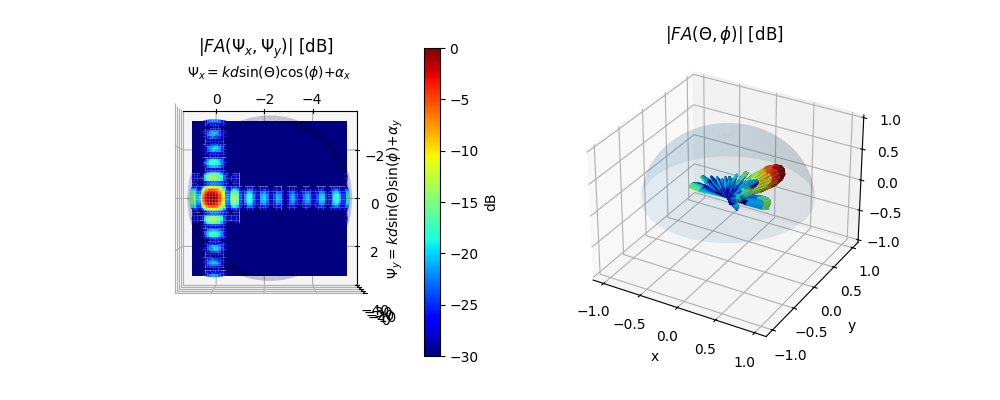

In [14]:
def respuesta_10():
    # Se considera:
    # Una agrupación de antenas isotrópicas sobre el plano XY
    # Repartidas en los nodos de una malla cuadrada de 11x11 elementos.
    # La separación entre elementos es de media longitud de onda en 
    # la dirección X, también en la dirección Y
    # Alimentación uniforme
    # En el origen el FA(Ψx=0,Ψy=0)=1
    # Diagrama de radiación en el espacio real con el lóbulo 
    # principal apuntando en la dirección (θ=45,φ=0)
    # Bajo las condiciones previas, la función debe devolver 3 cosas:
    # - Factor de agrupación en módulo en función de los ángulos 
    #   eléctricos ∣FA(Ψx,Ψy)∣
    # - Margen visible en Ψx
    # - Margen visible en Ψy
    # Edita a partir de aquí
    theta=np.pi/4
    alpha_x= -np.pi*np.sin(theta)
    alpha_y= -np.pi*np.sin(theta)*np.sin(0)
    margen_visible_Ψx=[-np.pi+alpha_x,np.pi+alpha_x]
    margen_visible_Ψy=[-np.pi+alpha_y,np.pi+alpha_y]
    FA=lambda Ψx,Ψy: abs((1/11**2)*np.sin(Ψx*11/2)/np.sin(Ψx/2)*np.sin(11*Ψy/2)/np.sin(Ψy/2))
    return[FA,margen_visible_Ψx,margen_visible_Ψy]

muestra_FA_2D(respuesta_10()[0],respuesta_10()[1],respuesta_10()[2],'|FA($\\Psi$)| [dB]')

## Acoplos entre fuentes

La misión de este apartado es trabajar el concepto de acoplo entre fuentes.
Vamos a trabajar usando campos estáticos. Sin embargo los pasos empleados para
resolver este problema son semajantes a los empleados en caso de los problemas de
régimen permanente sinusoidal. En ambos problemas la respuesta se
obtiene a base de integrar (sumar) las respuestas elementales
obtenidas a partir de excitaciones elementales. En ambos casos son integrales de
convolución en el espacio. Dependiendo si trabajamos con campos
estáticos u oscilantes, las integrales cambian, pero el concepto es muy similar.

Recordemos que el potencial $V$ creado por una carga puntual $Q$ es:
\begin{equation}
  V(\vec{r}) = \frac{Q}{4 \pi \epsilon_0|\vec{r}-\vec{r}'|} \label{eq:cargapuntual}
\end{equation}
donde $\vec{r}$ es el punto de observación, y $\vec{r}'$ la posición
de la carga

Imaginemos por un momento que tenemos dos cargas y sabemos el valor
del potencial en dos puntos $\vec{r}_1$ y $\vec{r}_2$. Está claro que
se podría encontrar el valor de las dos cargas $Q_1$ y $Q_2$
utilizando el siguiente sistema de dos ecuaciones y dos incógnitas
\begin{eqnarray}
  V(\vec{r}_1) \,=\, V_1 \!&=& \frac{Q_1}{4 \pi \epsilon_0R_{11}} + \frac{Q_2}{4 \pi \epsilon_0R_{12}}, \\
  V(\vec{r}_2) \,=\, V_2 \!&=& \frac{Q_1}{4 \pi \epsilon_0R_{21}} + \frac{Q_2}{4 \pi \epsilon_0R_{22}},
\end{eqnarray}
Donde $R_{ij}$ sería la distancia entre el punto de observación
$\vec{r}_i$ y el punto $\vec{r}'_j$ donde está la carga puntual $Q_j$

En el caso que nos ocupa  la incognita será una densidad
de carga electrica superficial sobre un parche cuadrado de conductor eléctrico
perfecto con un potencial constante respecto a la referencia. Así que es
necesario en general utilizar integrales para tener en cuenta el efecto de la
carga contenida en cada uno de las superficies elementales en que
dividiremos el parche. Cuando estudiemos la influencia de un cuadrado
elemental en el centro de otro cuadrado elemental vecino, asumiremos que
podemos considerar la carga total del primer cuadrado concentrada en su
centro. Pero al estudiar la influencia del cuadrado elemental n-ésimo sobre la tensión
observada en su propio centro, tendremos que hacer la integral
$\int\int \frac{a_n}{r}dxdy$ en la superficie del cuadrado elemental,
teniendo en cuenta la distancia $r$ desde cada elemento de densidad
de carga hasta el centro del propio cuadrado elemental, aunque la densidad de
carga $a_n$ es considerada constante en toda su superficie.

Lo que tenemos que calcular es la distribución espacial de la densidad
superficial de carga eléctrica, es decir el $a_n$ de cada cuadrado elemental
de un parche cuadrado de conductor eléctrico perfecto sabiendo que:
 - Su lado mide en total 1 metro 
 - Está situado sobre el plano XY
 - Su diagonal va de (0,0) a (1,1).
 - Vamos a subdividir el parche cuadrado en NxN cuadrados elementales iguales.
 - Su potencial $V(\vec{r})=1$ voltio respecto a tierra en cada punto
   de la placa (conocemos por tanto la respuesta en los centros de cada
   cuadrado elemental).
 - $\epsilon_0=8.854\cdot10^{-12}$ [F·m$^{−1}$]
 - Los puntos de observación estarán situados en el centro de cada cuadrado
   elemental.
 - Cada densidad de carga $a_n$ asumiremos que tiene un valor constante 
   dentro del n-ésimo cuadrado elemental y cero fuera de su propio cuadrado.

In [ ]:
def respuesta_11(N):
    # Debe devolver los siguientes arrays en función de N, 
    # siendo N*N igual al número total de cuadrados 
    # elementales considerados en el parche. Se pide:
    # 1) El array de voltajes vcm incluyendo la parte constante
    # vcm=vm*4πϵ0  donde vm=1 voltio
    # 2) El valor i de la integral de 1/r sobre un cuadrado
    #    elemental de lado 0.01 sin considerar an. 
    # 3) El array zmn que es lo que queda en el segundo miembro
    #    sin contar con 4πϵ0 (que pasa al primer miembro) ni an,
    #    que son las incógnitas
    # 4) El array an de densidades superficiales de carga en el
    #    cada cuadro elemental.
     
    # Edita a partir de aquí
    
    vcm=np.array([0,0])
    i=0
    zmn=np.zeros((2,2))
    an=np.array([0,0])
   
    return(vcm,i,zmn,an)

In [ ]:
from ftrlearn02 import muestra_densidad_de_carga_normalizada
muestra_densidad_de_carga_normalizada(respuesta_11(20))